### **SPAM/HAM Email Classifier using SVM — NPZ Dataset Version**

This notebook implements a spam email classifier using Support Vector Machines (SVM) with pre-featurized data loaded from a `.npz` file.

#### **Table of Contents**
1. [Setup and Imports](#1-setup-and-imports)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Data Preprocessing](#3-data-preprocessing)
4. [SVM Model Training](#4-svm-model-training)
5. [Model Evaluation](#5-model-evaluation)
6. [Test Predictions and Submission](#6-test-predictions-and-submission)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)


#### **1. Setup and Imports**

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Machine learning
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful!")


All imports successful!


#### **2. Data Loading and Exploration**

In [3]:
# Load the pre-featurized dataset from .npz file
data = np.load('./data/spam-data.npz')

training_data   = data['training_data']    # shape: (n_train, n_features)
training_labels = data['training_labels']  # shape: (n_train,)
test_data       = data['test_data']         # shape: (n_test, n_features)

print(f"Training data shape:   {training_data.shape}")
print(f"Training labels shape: {training_labels.shape}")
print(f"Test data shape:       {test_data.shape}")
print(f"\nFeature value range: [{training_data.min():.2f}, {training_data.max():.2f}]")
print(f"Label values:        {np.unique(training_labels)}")


Training data shape:   (4171, 32)
Training labels shape: (4171,)
Test data shape:       (1000, 32)

Feature value range: [0.00, 293.00]
Label values:        [0 1]


SPAM samples: 1200  (28.8%)
HAM  samples: 2971  (71.2%)


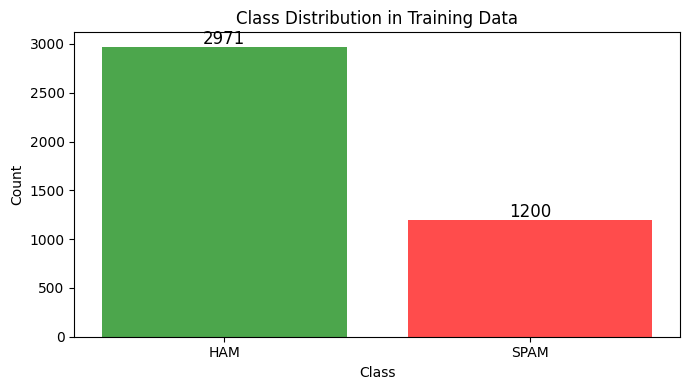

In [4]:
# Class distribution
n_spam = np.sum(training_labels == 1)
n_ham  = np.sum(training_labels == 0)
print(f"SPAM samples: {n_spam}  ({n_spam/len(training_labels)*100:.1f}%)")
print(f"HAM  samples: {n_ham}  ({n_ham/len(training_labels)*100:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(7, 4))
plt.bar(['HAM', 'SPAM'], [n_ham, n_spam], color=['green', 'red'], alpha=0.7)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
for i, count in enumerate([n_ham, n_spam]):
    plt.text(i, count + 30, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()


In [5]:
# Feature statistics
print('Per-feature summary:')
df_train = pd.DataFrame(training_data)
print(df_train.describe().T[['mean','std','min','max']].round(3))


Per-feature summary:
     mean    std  min    max
0   0.019  0.193  0.0    8.0
1   0.022  0.165  0.0    3.0
2   0.019  0.216  0.0    6.0
3   0.067  0.379  0.0    8.0
4   0.008  0.120  0.0    4.0
5   0.017  0.178  0.0    5.0
6   0.026  0.208  0.0    4.0
7   0.011  0.108  0.0    2.0
8   0.087  2.806  0.0  146.0
9   0.015  0.152  0.0    3.0
10  0.018  0.190  0.0    3.0
11  0.073  1.870  0.0   63.0
12  0.133  0.527  0.0    9.0
13  0.154  0.782  0.0   14.0
14  0.107  0.660  0.0   20.0
15  0.179  0.675  0.0   11.0
16  0.148  0.696  0.0   20.0
17  0.021  0.190  0.0    4.0
18  0.037  0.576  0.0   26.0
19  0.474  1.813  0.0   28.0
20  0.010  0.121  0.0    3.0
21  0.013  0.127  0.0    4.0
22  0.008  0.108  0.0    3.0
23  0.015  0.153  0.0    3.0
24  0.220  0.625  0.0   11.0
25  0.777  8.108  0.0  293.0
26  0.582  2.574  0.0   55.0
27  0.481  2.309  0.0   75.0
28  0.695  1.957  0.0   35.0
29  1.135  4.416  0.0  219.0
30  0.101  1.405  0.0   39.0
31  0.297  1.206  0.0   20.0


#### **3. Data Preprocessing**

The dataset is already featurized (32 numeric features per sample). We scale the features with `StandardScaler` and split off a validation set.

In [6]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(training_data)
X_test_scaled = scaler.transform(test_data)

y_train_all = training_labels

# Train / validation split (80/20, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_train_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_all
)

print(f"Training split:   {X_train.shape[0]} samples")
print(f"Validation split: {X_val.shape[0]} samples")


Training split:   3336 samples
Validation split: 835 samples


#### **4. SVM Model Training**

In [7]:
# Train a basic SVM (default hyperparameters)
print("Training SVM model...")

svm_model = SVC(random_state=RANDOM_STATE)
svm_model.fit(X_train, y_train)
print("Training complete!")
print(f"Accuracy on training split: {svm_model.score(X_train, y_train):.4f}")


Training SVM model...
Training complete!
Accuracy on training split: 0.8177


In [8]:
# 5-fold cross-validation on the full training set
print("Performing 5-fold cross-validation...")

cv_scores = cross_val_score(
    SVC(random_state=RANDOM_STATE),
    X_scaled, y_train_all,
    cv=5,
    scoring='accuracy'
)

print(f"CV scores:        {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Performing 5-fold cross-validation...
CV scores:        [0.80718563 0.79976019 0.80815348 0.78297362 0.82134293]
Mean CV accuracy: 0.8039 (+/- 0.0251)


#### **5. Model Evaluation**

In [9]:
# Evaluate on validation set
y_val_pred = svm_model.predict(X_val)

print("Validation Set Performance:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['HAM', 'SPAM']))


Validation Set Performance:
Accuracy: 0.8096

Classification Report:
              precision    recall  f1-score   support

         HAM       0.81      0.96      0.88       595
        SPAM       0.82      0.43      0.57       240

    accuracy                           0.81       835
   macro avg       0.81      0.70      0.72       835
weighted avg       0.81      0.81      0.79       835



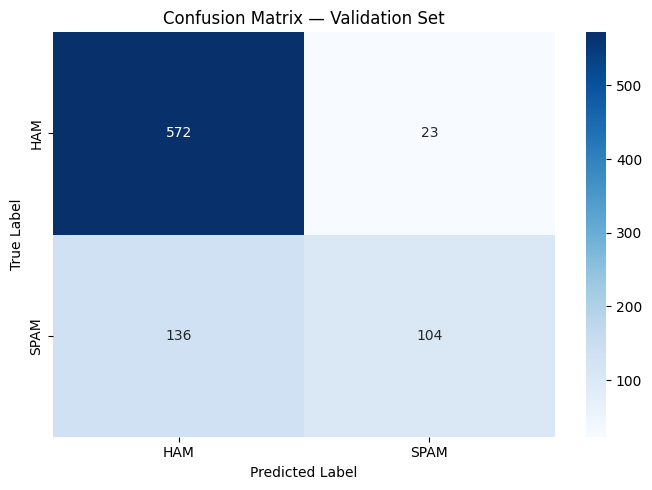

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['HAM', 'SPAM'],
            yticklabels=['HAM', 'SPAM'])
plt.title('Confusion Matrix — Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [11]:
# Train final model on ALL training data before making test predictions
print("Training final model on all training data...")

final_svm = SVC(random_state=RANDOM_STATE)
final_svm.fit(X_scaled, y_train_all)
print("Final model trained!")


Training final model on all training data...
Final model trained!


#### **6. Test Predictions and Submission**

In [26]:
# Generate predictions on test set
print("Generating predictions on test set...")
y_test_pred = final_svm.predict(X_test_scaled)

print(f"Test predictions shape: {y_test_pred.shape}")
print(f"Predicted SPAM: {sum(y_test_pred == 1)}")
print(f"Predicted HAM:  {sum(y_test_pred == 0)}")

val_accuracy = accuracy_score(y_val, final_svm.predict(X_val))
print("validation accuracy", val_accuracy)

Generating predictions on test set...
Test predictions shape: (1000,)
Predicted SPAM: 166
Predicted HAM:  834
validation accuracy 0.8323353293413174


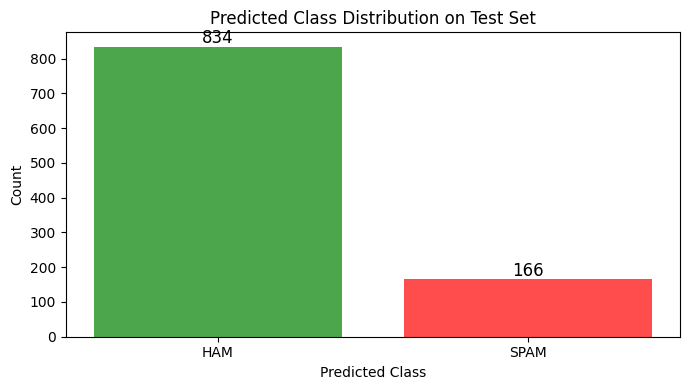

In [13]:
# Visualize test predictions distribution
plt.figure(figsize=(7, 4))
plt.bar(['HAM', 'SPAM'], [sum(y_test_pred==0), sum(y_test_pred==1)],
        color=['green', 'red'], alpha=0.7)
plt.title('Predicted Class Distribution on Test Set')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
for i, count in enumerate([sum(y_test_pred==0), sum(y_test_pred==1)]):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()


In [17]:
# Save predictions to CSV in Kaggle-accepted format
def results_to_csv(y_test, file_name):
    y_test = np.array(y_test).astype(int)
    df = pd.DataFrame({'Category': y_test})
    df.index += 1  # Kaggle expects 1-indexed IDs
    df.to_csv(file_name, index_label='Id')
    print(f"Predictions saved to {file_name}")
    return df

from datetime import datetime
ts = datetime.now().strftime('%Y_%m_%d_%H%_M')
sub_name = f'submission_{ts}.csv'
submission_df = results_to_csv(y_test_pred, sub_name)

print('\nSubmission file preview:')
print(submission_df.head(10))


Predictions saved to submission_2026_04_19_0941.csv

Submission file preview:
    Category
1          0
2          0
3          0
4          0
5          0
6          0
7          1
8          0
9          0
10         1


In [16]:
# Verify the submission file
verify_df = pd.read_csv(sub_name)
print("Submission file verification:")
print(f"Shape: {verify_df.shape}")
print(f"Columns: {verify_df.columns.tolist()}")
print("\nValue counts:")
print(verify_df['Category'].value_counts())
print("submission_file_name", sub_name)


Submission file verification:
Shape: (1000, 2)
Columns: ['Id', 'Category']

Value counts:
Category
0    834
1    166
Name: count, dtype: int64
submission_file_name submission_20260419093843.csv


#### **7. Hyperparameter Tuning**

Run this section to find better SVM hyperparameters. `RandomizedSearchCV` explores the parameter space efficiently. You can also try `GridSearchCV` or Optuna for a more thorough search.

In [19]:
best = gs_lin if gs_lin.best_score_ >= gs_rbf.best_score_ else gs_rbf
print("Best params:", best.best_params_)
print(f"Best CV accuracy: {best.best_score_:.4f}")

# Re-train on full training data with best params and generate new submission
best_model = best.best_estimator_
best_model.fit(X_scaled, y_train_all)
y_test_best = best_model.predict(X_test_scaled)

ts2 = datetime.now().strftime('%Y_%m_%d_%H%_M')
sub_name2 = f'submission_tuned_{ts2}.csv'
results_to_csv(y_test_best, sub_name2)
print(f"\nTuned submission saved as {sub_name2}")
print(f"Predicted SPAM: {sum(y_test_best==1)}, HAM: {sum(y_test_best==0)}")


Best params: {'tol': 0.001, 'shrinking': True, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': None, 'C': 10.0}
Best CV accuracy: 0.8228
Predictions saved to submission_tuned_2026_04_19_0942.csv

Tuned submission saved as submission_tuned_2026_04_19_0942.csv
Predicted SPAM: 203, HAM: 797
